In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import numpy as np
from IPython.display import Audio
from tqdm import tqdm
import random

In [2]:
ANNOTATION_DIR = "/kaggle/input/xltn-to-csv"
AUDIO_DIR = "/kaggle/input/bird-song/Audio"

AUDIO_TRAIN = os.path.join(AUDIO_DIR, "Training")
AUDIO_VAL = os.path.join(AUDIO_DIR, "Validation")
AUDIO_TEST = AUDIO_VAL

OUTPUT_PATH = "/kaggle/working/"

In [3]:
train_df = pd.read_csv(os.path.join(ANNOTATION_DIR, "train_annotation.csv"))
val_df = pd.read_csv(os.path.join(ANNOTATION_DIR, "val_annotation.csv"))
test_df = pd.read_csv(os.path.join(ANNOTATION_DIR, "test_annotation.csv"))

In [4]:
audit_df = train_df.copy()

audit_df["duration_sec"] = audit_df["end_time"] - audit_df["start_time"]
audit_df["bandwidth_hz"] = audit_df["f_high"] - audit_df["f_low"]
audit_df["center_freq_hz"] = (audit_df["f_high"] + audit_df["f_low"]) / 2

In [5]:
print("Number of boxes:", len(audit_df))
print("Number of species:", audit_df["species"].nunique())

Number of boxes: 5976
Number of species: 22


In [6]:
audit_df[["duration_sec", "bandwidth_hz", "center_freq_hz"]].describe(percentiles=[0.01, 0.05, 0.95, 0.99])

,duration_sec,bandwidth_hz,center_freq_hz
count,5976.000000,5976.000000,5976.000000
mean,2.539028,4576.297851,2503.137359
std,1.832704,1200.082802,611.919731
min,0.000021,-1678.395000,-839.197500
1%,0.725333,995.289000,1377.571875
5%,1.066667,2388.852500,1591.290000
50%,1.856000,4798.330000,2490.970000
95%,6.597333,6223.428750,3387.510000
99%,9.157333,7080.300000,4248.985000
max,15.146667,8008.090000,21349.600000


In [7]:
species_stats = audit_df.groupby("species").agg(
    num_boxes=("species", "count"),
    mean_duration=("duration_sec", "mean"),
    mean_bandwidth=("bandwidth_hz", "mean")
).sort_values("num_boxes", ascending=False)

species_stats.head(10)

,num_boxes,mean_duration,mean_bandwidth
species,,,
Paridae_Saxicola_rubetra,1475,1.671474,4829.576520
Troglodytidae_Troglodytes_troglodytes,627,4.642633,5742.681451
Troglodytidae_Troglodytes_aedon,570,2.214437,4472.926367
Turdidae_Catharus_aurantiirostris,547,1.603837,5076.350027
Turdidae_Catharus_guttatus,420,1.498025,2869.564348
Paridae_Saxicola_rubicola,411,1.655825,4599.361428
Fringillidae_Serinus_serinus,387,2.967480,6060.386041
Turdidae_Catharus_fuscater,225,1.152403,1646.106618
Troglodytidae_Troglodytes_hiemalis,197,7.755628,5335.749822


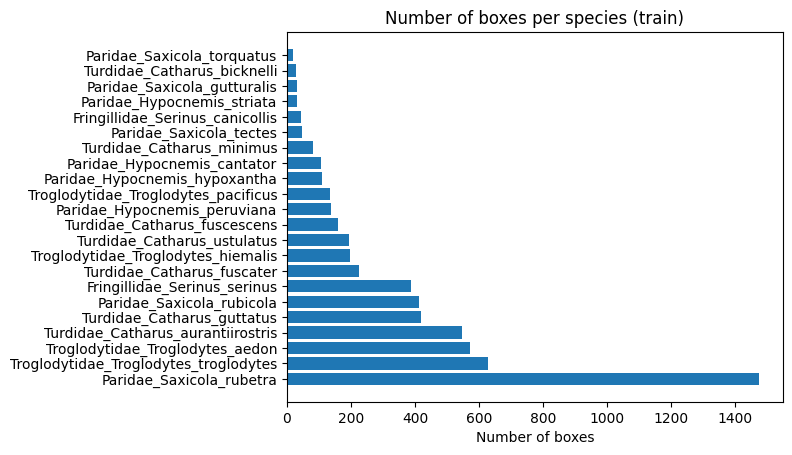

In [8]:
species_counts = audit_df["species"].value_counts()

plt.figure()
plt.barh(species_counts.index, species_counts.values)
plt.xlabel("Number of boxes")
plt.title("Number of boxes per species (train)")
plt.show()

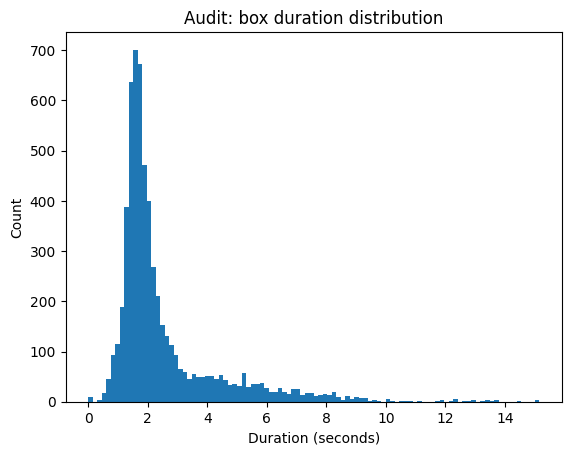

In [9]:
plt.figure()
plt.hist(audit_df["duration_sec"], bins=100)
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.title("Audit: box duration distribution")
plt.show()

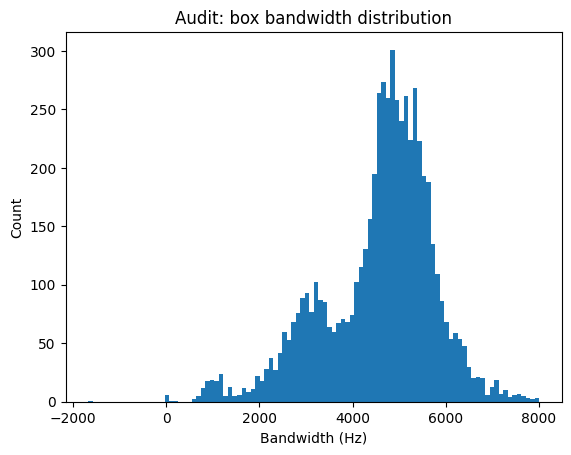

In [10]:
plt.figure()
plt.hist(audit_df["bandwidth_hz"], bins=100)
plt.xlabel("Bandwidth (Hz)")
plt.ylabel("Count")
plt.title("Audit: box bandwidth distribution")
plt.show()

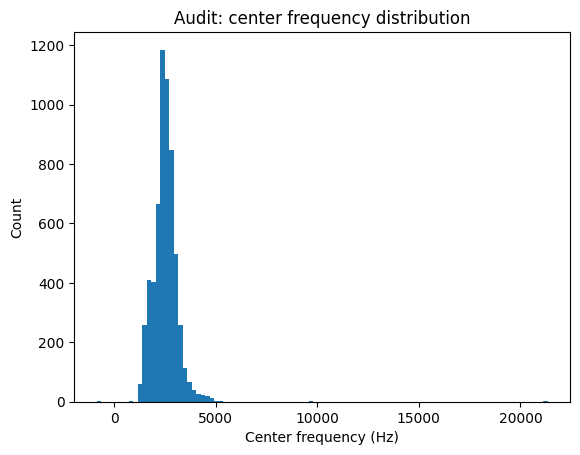

In [11]:
plt.figure()
plt.hist(audit_df["center_freq_hz"], bins=100)
plt.xlabel("Center frequency (Hz)")
plt.ylabel("Count")
plt.title("Audit: center frequency distribution")
plt.show()

In [12]:
sample_df = train_df.sample(n=5, random_state=64).reset_index(drop=True)
sample_df

,audio_file,split,start_frame,end_frame,start_time,end_time,f_low,f_high,species
0,Paridae_Saxicola_rubetra_Norway_2016-05-30_XC3...,Training,3259392,3329024,67.904000,69.354667,0.00,4540.300,Paridae_Saxicola_rubetra
1,Paridae_Saxicola_rubetra_United Kingdom_2017-0...,Training,30408704,30493696,633.514667,635.285333,0.00,5022.065,Paridae_Saxicola_rubetra
2,Turdidae_Catharus_guttatus_United States_2010-...,Training,148480,219136,3.093333,4.565333,706.59,3581.870,Turdidae_Catharus_guttatus
3,Turdidae_Catharus_ustulatus_United States_2015...,Training,23552,123904,0.490667,2.581333,0.00,4079.187,Turdidae_Catharus_ustulatus
4,Troglodytidae_Troglodytes_troglodytes_Ireland_...,Training,87040,348160,1.813333,7.253333,0.00,5480.295,Troglodytidae_Troglodytes_troglodytes


In [13]:
def play_box(row, audio_dir, sample_rate=48000):
    audio_path = os.path.join(audio_dir, row["split"], row["audio_file"])
    
    y, sr = librosa.load(audio_path, sr=sample_rate, mono=True)
    
    start = int(row["start_time"] * sr)
    end = int(row["end_time"] * sr)
    
    y_box = y[start:end]
    
    print("Species:", row["species"])
    print(f"Duration: {row['end_time'] - row['start_time']:.2f} s")
    print(f"Freq range: {row['f_low']:.0f}–{row['f_high']:.0f} Hz")
    
    return Audio(y_box, rate=sr)

In [14]:
for i in range(len(sample_df)):
    display(play_box(sample_df.loc[i], AUDIO_DIR))

Species: Paridae_Saxicola_rubetra
Duration: 1.45 s
Freq range: 0–4540 Hz


Species: Paridae_Saxicola_rubetra
Duration: 1.77 s
Freq range: 0–5022 Hz


Species: Turdidae_Catharus_guttatus
Duration: 1.47 s
Freq range: 707–3582 Hz


Species: Turdidae_Catharus_ustulatus
Duration: 2.09 s
Freq range: 0–4079 Hz


Species: Troglodytidae_Troglodytes_troglodytes
Duration: 5.44 s
Freq range: 0–5480 Hz


In [15]:
def extract_logmel(
    y,
    sr=48000,
    n_fft=2048,
    hop_length=512,
    n_mels=128,
    fmin=1000,
    fmax=8000
):
    S = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=n_fft,
        n_mels=n_mels,
        fmin=fmin,
        fmax=fmax,
        power=2.0
    )
    S_db = librosa.power_to_db(S, ref=np.max)
    return S_db

def fix_time_dim(spec, target_frames):
    T = spec.shape[1]

    if T == target_frames:
        return spec

    if T < target_frames:
        pad = target_frames - T
        return np.pad(spec, ((0, 0), (0, pad)), mode="constant")

    start = (T - target_frames) // 2
    return spec[:, start:start + target_frames]

def extract_box_spectrogram(
    row,
    audio_dir,
    sr=48000,
    target_duration=3.0
):
    audio_path = os.path.join(audio_dir, row["audio_file"])

    y, _ = librosa.load(audio_path, sr=sr, mono=True)

    start = int(row["start_time"] * sr)
    end = int(row["end_time"] * sr)
    y_box = y[start:end]

    spec = extract_logmel(y_box, sr=sr)

    target_frames = int(target_duration * sr / 512)
    spec = fix_time_dim(spec, target_frames)

    return spec

In [16]:
def save_spectrogram(
    spec,
    save_dir,
    filename
):
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, filename)
    np.save(save_path, spec)

def export_spectrograms(
    df,
    audio_dir,
    output_root,
    split="train"
):
    for idx, row in tqdm(df.iterrows(), total=len(df)):
        spec = extract_box_spectrogram(row=row, audio_dir=audio_dir)

        label = row["species"]
        save_dir = os.path.join(output_root, split, label)

        fname = f"{row['audio_file'].split('.')[0]}_{idx}.npy"

        save_spectrogram(spec=spec, save_dir=save_dir, filename=fname)

In [17]:
export_spectrograms(
    df=train_df,
    audio_dir=AUDIO_TRAIN,
    output_root=os.path.join(OUTPUT_PATH, "spectrograms"),
    split="train"
)

export_spectrograms(
    df=val_df,
    audio_dir=AUDIO_VAL,
    output_root=os.path.join(OUTPUT_PATH, "spectrograms"),
    split="val"
)

export_spectrograms(
    df=test_df,
    audio_dir=AUDIO_TEST,
    output_root=os.path.join(OUTPUT_PATH, "spectrograms"),
    split="test"
)

  1%|          | 42/5976 [00:08<19:49,  4.99it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1
  warnings.warn(
  8%|▊         | 450/5976 [01:47<15:42,  5.86it/s]Note: Illegal Audio-MPEG-Header 0x00000000 at offset 1816505.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
  8%|▊         | 451/5976 [01:47<20:54,  4.40it/s]Note: Illegal Audio-MPEG-Header 0x00000000 at offset 1816505.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
  8%|▊         | 452/5976 [01:48<24:37,  3.74it/s]Note: Illegal Audio-MPEG-Header 0x00000000 at offset 1816505.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
  8%|▊         | 453/5976 [01:48<26:50,  3.43it/s]Note: Illegal Audio-MPEG-Header 0x00000000 at offset 1816505.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
  8%|▊         | 454/5976 [01:49<28:41,  3.21it/s]